# Two-step nucleation (2S) ? literature-aligned summary
- W(i,n) from composite-cluster CNT (Kashchiev/Auer)
- Detailed-balance symmetric rates exp(??W/2)
- Outputs: w(i,n) heatmap, J_i(t) heatmap & trajectories (s_co=2.5)

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

try:
    import scienceplots
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.style.use("default")

plt.rcParams.update({
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.6,
    "xtick.major.width": 1.6,
    "ytick.major.width": 1.6,
    "xtick.minor.width": 1.2,
    "ytick.minor.width": 1.2,
    "lines.linewidth": 2.2,
})

In [2]:
# Parameters (fixed s_co=2.5)
T = 220.0
SCO_LIST = [2.5]
s_cm = 0.5
s_co = SCO_LIST[0]
s_mo = s_co - s_cm

# interfacial terms (gamma_co = gamma_cm + gamma_mo in paper)
gamma_cm = 2.6
gamma_mo = 12.8
gamma_co = 15.4

f0 = 1.0e5
k0 = 0.5e5  # internal ordering prefactor (set similar scale)
C1_base = 1.6e21
M = 160  # reduced for speed (paper used larger; adjust as needed)

# time grid (seconds)
t_max = 40e-6
N_eval = 2000
t_eval = np.linspace(0.0, t_max, N_eval)

In [3]:
# Triangular indexing (1 <= n <= i <= M-1)

def tri_index_maps(M):
    pair2idx = {}
    idx2pair = []
    k = 0
    for i in range(1, M):
        for n in range(1, i + 1):
            pair2idx[(i, n)] = k
            idx2pair.append((i, n))
            k += 1
    return pair2idx, np.array(idx2pair, dtype=int)

PAIR2IDX, IDX2PAIR = tri_index_maps(M)
Ntri = len(IDX2PAIR)

In [4]:
# Free energy W(i,n) (composite cluster)
# W = -s_mo (i-n) - s_co n + gamma_mo (i-n)^{2/3} + gamma_cm n^{2/3} + gamma_co (i-n)^{2/3}

C1 = C1_base * np.exp(s_co)


def w_total(i, n, s_co):
    if n > i or i <= 0 or n <= 0:
        return np.inf
    shell = i - n
    return (
        -s_mo * shell
        -s_co * n
        + gamma_mo * shell ** (2/3)
        + gamma_cm * n ** (2/3)
        + gamma_co * shell ** (2/3)
    )


def make_W_C():
    W = np.empty(Ntri, dtype=float)
    for k, (i, n) in enumerate(IDX2PAIR):
        W[k] = w_total(i, n, s_co)
    w11 = w_total(1, 1, s_co)
    C = C1 * np.exp(w11 - W)
    return W, C


def crit_sizes(s_co):
    i_star = (2 * (gamma_mo + gamma_co) / (3 * s_mo)) ** 3
    n_star = (2 * gamma_cm / (3 * s_cm)) ** 3
    ico_star = (2 * gamma_co / (3 * s_co)) ** 3
    return int(np.ceil(i_star)), int(np.ceil(n_star)), int(np.ceil(ico_star))

In [5]:
# Symmetric rates (detailed balance): r_? = pref * exp(? ?W / 2)
beta = 1.0  # set kT=1 units

def pref_attach(i):
    return f0 * (max(i, 1) ** (2/3))

def pref_order(i, n):
    return k0 * (max(n, 1) ** (2/3))


def build_coeffs(W):
    Wmap = {(i, n): W[PAIR2IDX[(i, n)]] for (i, n) in PAIR2IDX}
    # forward/backward along i (size) and n (ordering)
    def f_plus(i, n):
        if i + 1 >= M:
            return 0.0
        dW = Wmap[(i + 1, n)] - Wmap[(i, n)]
        return pref_attach(i) * np.exp(-0.5 * beta * dW)

    def f_minus(i, n):
        if i + 1 >= M:
            return 0.0
        dW = Wmap[(i + 1, n)] - Wmap[(i, n)]
        return pref_attach(i) * np.exp(0.5 * beta * dW)

    def k_plus(i, n):
        if n + 1 > i:
            return 0.0
        dW = Wmap[(i, n + 1)] - Wmap[(i, n)]
        return pref_order(i, n) * np.exp(-0.5 * beta * dW)

    def k_minus(i, n):
        if n + 1 > i:
            return 0.0
        dW = Wmap[(i, n + 1)] - Wmap[(i, n)]
        return pref_order(i, n) * np.exp(0.5 * beta * dW)

    return f_plus, f_minus, k_plus, k_minus

In [6]:
# Sparse pattern and RHS

def jac_sparsity_pattern():
    rows, cols = [], []
    def add(r, c):
        rows.append(r); cols.append(c)
    for k, (i, n) in enumerate(IDX2PAIR):
        add(k, k)
        if i + 1 < M:
            add(k, PAIR2IDX[(i + 1, n)])
        if i - 1 >= 1 and n <= i - 1:
            add(k, PAIR2IDX[(i - 1, n)])
        if n + 1 <= i:
            add(k, PAIR2IDX[(i, n + 1)])
        if n - 1 >= 1:
            add(k, PAIR2IDX[(i, n - 1)])
    return sp.csr_matrix((np.ones(len(rows), dtype=bool), (rows, cols)), shape=(Ntri, Ntri))

JAC_SP = jac_sparsity_pattern()


def make_rhs(f_plus, f_minus, k_plus, k_minus):
    def rhs(t, F):
        dF = np.zeros_like(F)
        F[PAIR2IDX[(1, 1)]] = 1.0  # boundary condition
        for k, (i, n) in enumerate(IDX2PAIR):
            val = 0.0
            # along i
            if i + 1 < M:
                idx_ip1 = PAIR2IDX[(i + 1, n)]
                fp = f_plus(i, n); fm = f_minus(i, n)
                flux = fp * F[k] - fm * F[idx_ip1]
                val -= flux
                dF[idx_ip1] += flux
            if n + 1 <= i:
                idx_np1 = PAIR2IDX[(i, n + 1)]
                kp = k_plus(i, n); km = k_minus(i, n)
                flux = kp * F[k] - km * F[idx_np1]
                val -= flux
                dF[idx_np1] += flux
            dF[k] += val
        return dF
    return rhs

In [7]:
# Nucleation rates: net attach flux across i -> i+1 for each i (summed over n)

def compute_J_attach(F, f_plus, f_minus):
    J_layer = np.zeros(M)
    for i in range(1, M - 1):
        net = 0.0
        for n in range(1, i + 1):
            k = PAIR2IDX[(i, n)]
            kp1 = PAIR2IDX[(i + 1, n)] if (i + 1 < M) else None
            if kp1 is None:
                continue
            net += f_plus(i, n) * F[k] - f_minus(i, n) * F[kp1]
        J_layer[i] = net
    return J_layer

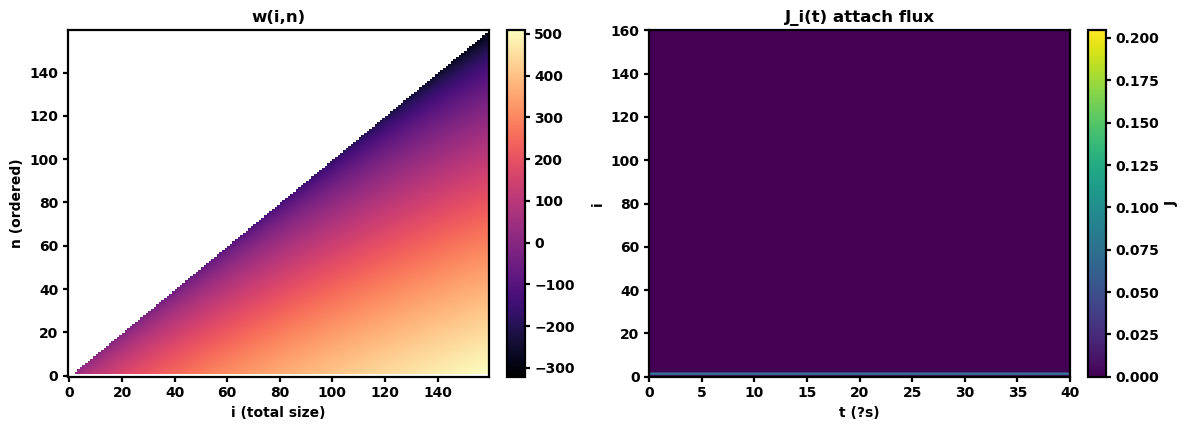

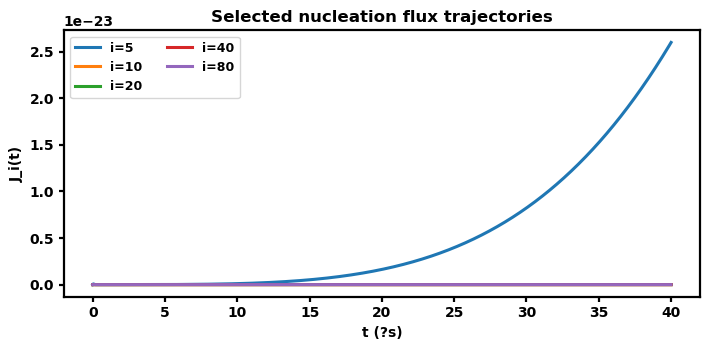

In [8]:
# Run and plot

def run_and_plot():
    W, C = make_W_C()
    f_plus, f_minus, k_plus, k_minus = build_coeffs(W)
    rhs = make_rhs(f_plus, f_minus, k_plus, k_minus)

    F0 = np.zeros(Ntri, dtype=float)
    F0[PAIR2IDX[(1, 1)]] = 1.0

    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), F0, method="BDF", t_eval=t_eval,
                    jac_sparsity=JAC_SP, atol=1e-9, rtol=1e-6, max_step=5e-8)
    if not sol.success:
        raise RuntimeError(sol.message)

    # W heatmap (mask i<n)
    w_grid = np.full((M, M), np.nan)
    for i in range(1, M):
        for n in range(1, i + 1):
            w_grid[i, n] = w_total(i, n, s_co)

    # J_i(t)
    J_time = []
    for j in range(len(sol.t)):
        J_time.append(compute_J_attach(sol.y[:, j], f_plus, f_minus))
    J_time = np.array(J_time)  # shape (T, M)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
    im0 = axes[0].imshow(w_grid.T, origin="lower", cmap="magma", aspect="auto")
    axes[0].set_xlabel("i (total size)")
    axes[0].set_ylabel("n (ordered)")
    axes[0].set_title("w(i,n)")
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    im1 = axes[1].imshow(J_time.T, origin="lower", cmap="viridis", aspect="auto",
                         extent=[sol.t[0]*1e6, sol.t[-1]*1e6, 0, M])
    axes[1].set_xlabel("t (?s)")
    axes[1].set_ylabel("i")
    axes[1].set_title("J_i(t) attach flux")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="J")
    plt.tight_layout()
    plt.show()

    # Trajectories of selected i
    plt.figure(figsize=(7.2, 3.6))
    t_us = sol.t * 1e6
    for i_sel in [5, 10, 20, 40, 80]:
        if i_sel >= M:
            continue
        plt.plot(t_us, J_time[:, i_sel], label=f"i={i_sel}")
    plt.xlabel("t (?s)")
    plt.ylabel("J_i(t)")
    plt.title("Selected nucleation flux trajectories")
    plt.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

run_and_plot()